# Notebook 02 — UCI Mushroom Benchmark

Benchmark the three optimizers on the UCI Mushroom dataset (Agaricus Lepiota):  
8 124 samples, 22 nominal attributes → 111 one-hot features, binary target (edible/poisonous).

The paper (§5.2) uses a 50-neuron enriched version of the dataset.

**Goals**
- Longer training cycles (up to 20 000 iterations) for STE and Proximal.
- 10 independent restarts per method to estimate variance.
- Identify the method that achieves the best F1 after full crystallization.
- Extract and interpret the symbolic Łukasiewicz formula from the best model.
- Assess feature sparsity: how many of the 111 input features actually contribute?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from luknn.benchmark.datasets import load_mushroom
from luknn.layers.lukasiewicz_linear import LukasiewiczNet
from luknn.optimizers import LMOptimizer, STEOptimizer, ProximalOptimizer
from luknn.benchmark.metrics import (
    compute_accuracy, compute_f1, compute_lambda_similarity, compute_delta_n,
)
from luknn.extraction.extractor import extract_formula

print('luknn ready — torch', torch.__version__)

luknn ready — torch 2.12.0+cpu


## 1 · Experiment parameters

In [2]:
# ── Parameters ───────────────────────────────────────────────────────────────
N_TRIALS       = 10
MAX_ITER_LM    = 400    # LM is expensive with Jacobian; 400 is already long
MAX_ITER_STE   = 20000  # STE needs many gradient steps
MAX_ITER_PROX  = 15000
TOL_MSE        = 0.05   # relaxed for this harder dataset
HIDDEN_LAYERS  = [16, 8]  # wider than truth-table nets to handle 111 features
BASE_SEED      = 7
ENRICH         = True   # add half-valued negative examples (paper §5)
RESULTS_DIR    = '../results/mushroom'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Optimizer hyper-parameters
LM_PARAMS   = dict(mu_init=0.01, patience=50, crystallize_n=2,
                   prune=True, batch_size=512)
STE_PARAMS  = dict(lr=0.003, clip_grad=1.0)
PROX_PARAMS = dict(lr=0.005, lambda_sparse=0.001, lambda_attract=0.05,
                   prox_threshold=0.0003, phase1_fraction=0.65)

OPTIMIZER_MODE = {'LM': 'continuous', 'STE': 'ste', 'Proximal': 'clamp'}
print('Parameters set.')

Parameters set.


## 2 · Dataset exploration

Train: torch.Size([9866, 111])  Test: torch.Size([2466, 111])
Features: 111
Target balance (train): 0.341 edible
Target balance (test):  0.343 edible


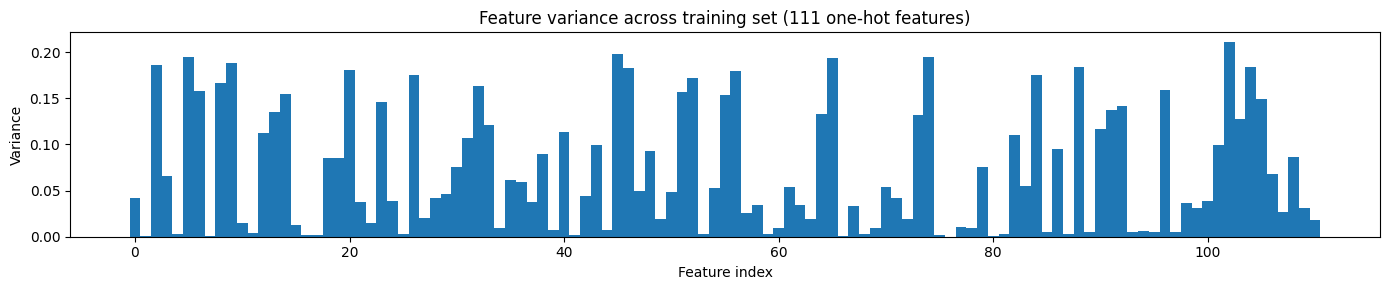

In [3]:
ds0 = load_mushroom(enrich=ENRICH, seed=BASE_SEED)
N_FEATURES = ds0.n_features

print(f'Train: {ds0.X_train.shape}  Test: {ds0.X_test.shape}')
print(f'Features: {N_FEATURES}')
print(f'Target balance (train): {ds0.y_train.mean():.3f} edible')
print(f'Target balance (test):  {ds0.y_test.mean():.3f} edible')

# Feature variance (informative features have higher variance)
var = ds0.X_train.var(dim=0).numpy()
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(len(var)), var, width=1.0)
ax.set_xlabel('Feature index')
ax.set_ylabel('Variance')
ax.set_title('Feature variance across training set (111 one-hot features)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_variance.png', dpi=150)
plt.show()

## 3 · Training helper

In [4]:
import time

def run_trial(method, trial):
    seed = BASE_SEED + trial * 1000
    torch.manual_seed(seed)
    np.random.seed(seed)

    ds = load_mushroom(enrich=ENRICH, seed=seed)
    mode = OPTIMIZER_MODE[method]
    model = LukasiewiczNet(ds.n_features, HIDDEN_LAYERS, mode=mode)

    if method == 'LM':
        opt = LMOptimizer(model, **LM_PARAMS)
        max_iter = MAX_ITER_LM
    elif method == 'STE':
        opt = STEOptimizer(model, **STE_PARAMS)
        max_iter = MAX_ITER_STE
    else:
        opt = ProximalOptimizer(model, **PROX_PARAMS)
        max_iter = MAX_ITER_PROX

    t0 = time.time()
    result = opt.train(ds.X_train, ds.y_train,
                       tol_mse=TOL_MSE, max_iter=max_iter, verbose=False)
    elapsed = time.time() - t0

    with torch.no_grad():
        pred = model(ds.X_test)

    acc  = compute_accuracy(pred, ds.y_test)
    f1   = compute_f1(pred, ds.y_test)
    lam  = compute_lambda_similarity(model, ds.X_test, ds.y_test)
    dn   = compute_delta_n(model)
    crys = dn < 1e-3

    # Count active (non-zero) input weights in layer 0
    W0 = model.weight_matrix_repr()[0][0]
    active_features = (W0.abs() > 0.5).any(dim=0).sum().item()

    formula_str = None
    if crys:
        try:
            er = extract_formula(model, n_values=3)
            formula_str = er.formula
        except Exception as e:
            formula_str = f'[error: {e}]'

    return {
        'method': method, 'trial': trial,
        'mse': result.final_mse, 'accuracy': acc, 'f1': f1,
        'lambda': lam, 'delta_n': dn, 'crystallized': crys,
        'converged': result.converged, 'iterations': result.iterations,
        'active_features': active_features,
        'time_s': elapsed,
        'extracted_formula': formula_str,
        'mse_history': result.mse_history,
        'model': model, 'dataset': ds,
    }

print('Helper ready.')

Helper ready.


## 4 · Full benchmark

**LM** is the slowest per trial (Jacobian computation).  
**STE / Proximal** use gradient descent — 20k iterations.

Expected runtime: LM ~10 min, STE ~15 min, Proximal ~15 min total (CPU).

In [5]:
all_rows    = []
all_records = []

for method in ['LM', 'STE', 'Proximal']:
    successes = 0
    t_start = time.time()
    for trial in range(N_TRIALS):
        rec = run_trial(method, trial)
        all_records.append(rec)
        row = {k: v for k, v in rec.items() if k not in ('mse_history','model','dataset')}
        all_rows.append(row)
        if rec['crystallized']:
            successes += 1
        print(f'  {method} trial {trial}: '
              f'mse={rec["mse"]:.4f}  f1={rec["f1"]:.3f}  '
              f'crys={rec["crystallized"]}  Δ(N)={rec["delta_n"]:.4f}  '
              f'active={rec["active_features"]}  {rec["time_s"]:.1f}s')
    elapsed = time.time() - t_start
    print(f'{method}: {successes}/{N_TRIALS} crystallized  total {elapsed:.1f}s\n')

df = pd.DataFrame(all_rows)
df.to_csv(f'{RESULTS_DIR}/full_benchmark.csv', index=False)
print('Benchmark complete.')

  LM trial 0: mse=0.1289  f1=0.881  crys=False  Δ(N)=1151.0266  active=1  17.3s
  LM trial 1: mse=0.6570  f1=0.501  crys=False  Δ(N)=1158.9769  active=1  21.3s
  LM trial 2: mse=0.3042  f1=0.289  crys=False  Δ(N)=598.6356  active=77  12.7s
  LM trial 3: mse=0.3382  f1=0.000  crys=False  Δ(N)=971.4973  active=0  3.5s
  LM trial 4: mse=0.3395  f1=0.000  crys=False  Δ(N)=988.8264  active=21  6.0s
  LM trial 5: mse=0.2907  f1=0.278  crys=True  Δ(N)=0.0000  active=24  8.9s
  LM trial 6: mse=0.0738  f1=0.878  crys=False  Δ(N)=607.0068  active=69  18.8s
  LM trial 7: mse=0.3409  f1=0.000  crys=False  Δ(N)=992.7816  active=18  3.8s
  LM trial 8: mse=0.3411  f1=0.000  crys=False  Δ(N)=911.0648  active=22  5.9s
  LM trial 9: mse=0.1436  f1=0.602  crys=True  Δ(N)=0.0000  active=1  16.3s
LM: 2/10 crystallized  total 200.3s

  STE trial 0: mse=0.0541  f1=0.880  crys=True  Δ(N)=0.0000  active=111  4.4s
  STE trial 1: mse=0.3430  f1=0.000  crys=True  Δ(N)=0.0000  active=111  4.4s
  STE trial 2: mse=0

## 5 · Summary statistics

In [6]:
pd.set_option('display.float_format', '{:.4f}'.format)

agg = df.groupby('method').agg(
    mse_mean=('mse','mean'), mse_std=('mse','std'),
    acc_mean=('accuracy','mean'), acc_std=('accuracy','std'),
    f1_mean=('f1','mean'), f1_std=('f1','std'),
    f1_max=('f1','max'),
    lambda_mean=('lambda','mean'),
    delta_n_mean=('delta_n','mean'),
    crys_rate=('crystallized','mean'),
    conv_rate=('converged','mean'),
    active_mean=('active_features','mean'),
    time_mean=('time_s','mean'),
).round(4)

print('=== Mushroom benchmark — aggregate results ===')
agg

=== Mushroom benchmark — aggregate results ===


,mse_mean,mse_std,acc_mean,acc_std,f1_mean,f1_std,f1_max,lambda_mean,delta_n_mean,crys_rate,conv_rate,active_mean,time_mean
method,,,,,,,,,,,,,
LM,0.2958,0.1628,0.6409,0.1408,0.3428,0.3567,0.8805,0.7324,737.9816,0.2000,0.2000,23.4000,11.4481
Proximal,0.3411,0.0019,0.6584,0.0076,0.0000,0.0000,0.0000,0.7106,0.0000,1.0000,0.0000,0.0000,0.8642
STE,0.1683,0.1182,0.7987,0.1013,0.6242,0.3341,0.8797,0.8378,0.0000,1.0000,0.0000,111.0000,3.1326


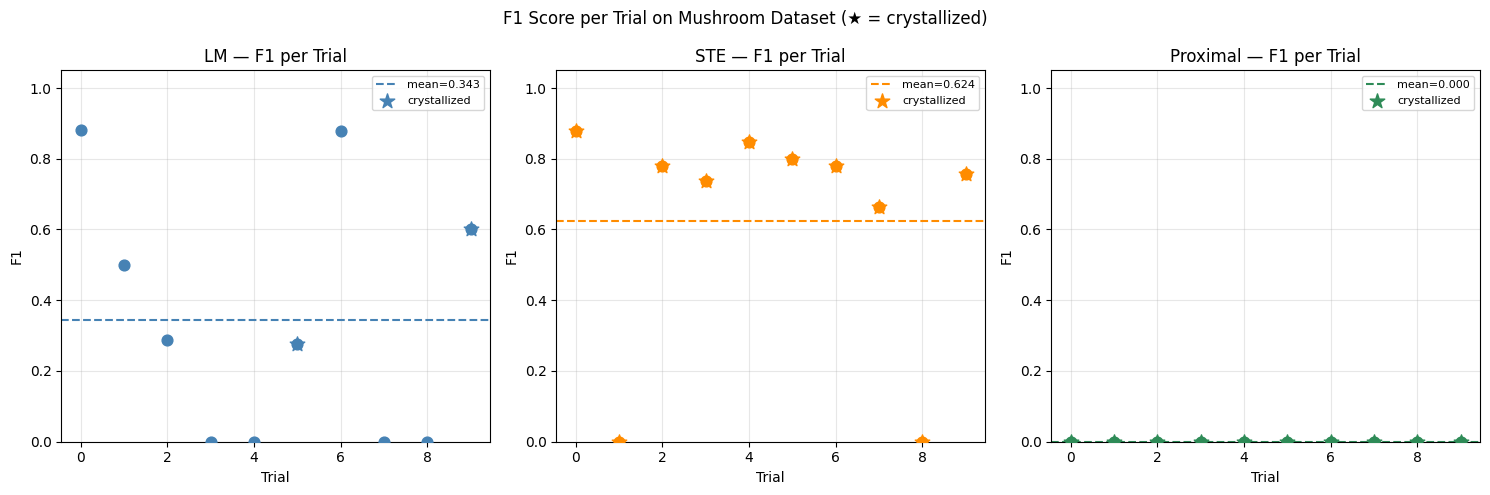

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

METHODS = ['LM', 'STE', 'Proximal']
COLORS  = ['steelblue', 'darkorange', 'seagreen']

# F1 distribution
for ax, method, color in zip(axes, METHODS, COLORS):
    sub = df[df['method'] == method]
    ax.scatter(sub['trial'], sub['f1'], color=color, s=60, zorder=3)
    ax.axhline(sub['f1'].mean(), color=color, linestyle='--', linewidth=1.5,
               label=f'mean={sub["f1"].mean():.3f}')
    # Mark crystallized vs not
    crys = sub[sub['crystallized']]
    if not crys.empty:
        ax.scatter(crys['trial'], crys['f1'], color=color, s=120,
                   marker='*', zorder=4, label='crystallized')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Trial')
    ax.set_ylabel('F1')
    ax.set_title(f'{method} — F1 per Trial')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('F1 Score per Trial on Mushroom Dataset (★ = crystallized)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/f1_per_trial.png', dpi=150)
plt.show()

## 6 · Learning curves

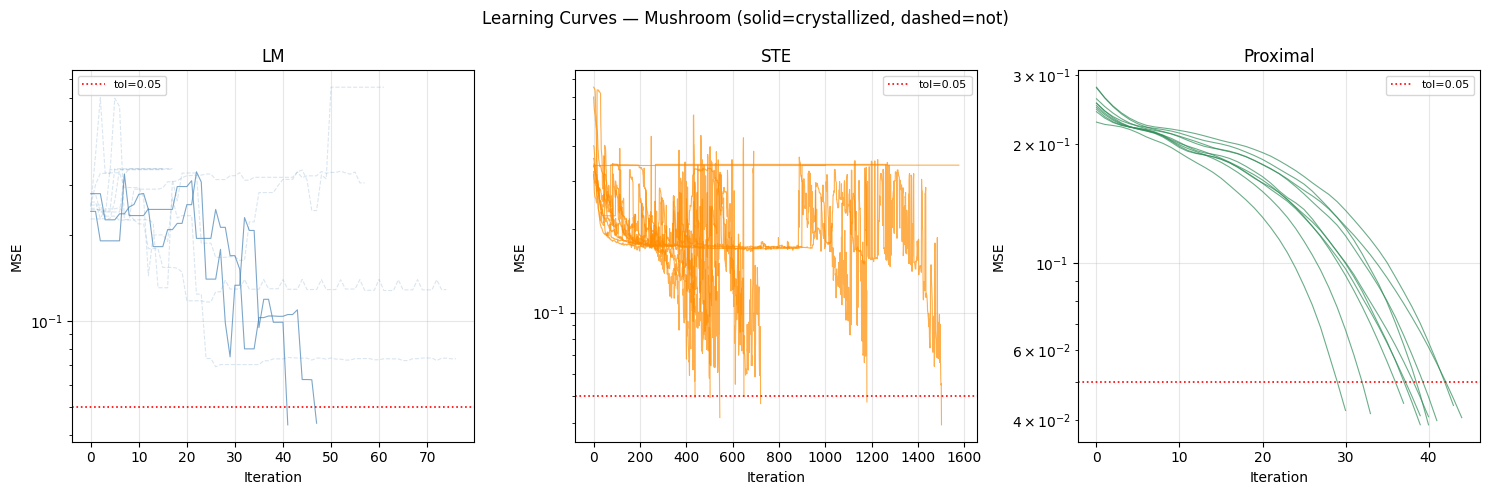

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method, color in zip(axes, METHODS, COLORS):
    recs = [r for r in all_records if r['method'] == method]
    for r in recs:
        hist = r['mse_history']
        if hist:
            alpha = 0.7 if r['crystallized'] else 0.2
            ls = '-' if r['crystallized'] else '--'
            ax.semilogy(hist, color=color, alpha=alpha, linewidth=0.8, linestyle=ls)
    ax.axhline(TOL_MSE, color='red', linestyle=':', linewidth=1.2,
               label=f'tol={TOL_MSE}')
    ax.set_title(f'{method}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves — Mushroom (solid=crystallized, dashed=not)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/learning_curves.png', dpi=150)
plt.show()

## 7 · Feature sparsity analysis

After crystallization, weights ∈ {−1, 0, 1}.  
Count how many of the 111 input features have at least one non-zero weight in layer 0.

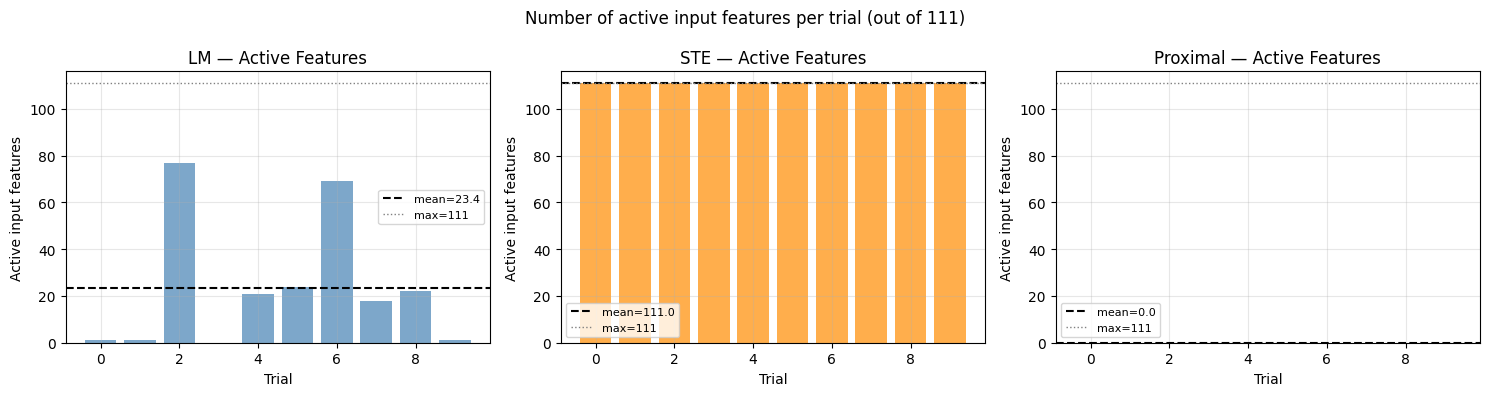

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, method, color in zip(axes, METHODS, COLORS):
    crys_recs = [r for r in all_records if r['method'] == method]
    if not crys_recs:
        ax.set_title(f'{method}: no data')
        continue

    active_counts = [r['active_features'] for r in crys_recs]
    ax.bar(range(len(active_counts)), active_counts, color=color, alpha=0.7)
    ax.axhline(np.mean(active_counts), color='black', linestyle='--',
               linewidth=1.5, label=f'mean={np.mean(active_counts):.1f}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Active input features')
    ax.set_title(f'{method} — Active Features')
    ax.set_ylim(0, N_FEATURES + 5)
    ax.axhline(N_FEATURES, color='grey', linestyle=':', linewidth=1,
               label=f'max={N_FEATURES}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Number of active input features per trial (out of 111)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/active_features.png', dpi=150)
plt.show()

## 8 · Best model — weight inspection

In [10]:
# Best model overall by F1
best_row = df.loc[df['f1'].idxmax()]
best_rec = all_records[best_row.name]
print(f'Best model: {best_row["method"]} trial {int(best_row["trial"])} '
      f'F1={best_row["f1"]:.4f} acc={best_row["accuracy"]:.4f} '
      f'Δ(N)={best_row["delta_n"]:.6f} crystallized={best_row["crystallized"]}')

model = best_rec['model']
layers = model.weight_matrix_repr()

for li, (W, b) in enumerate(layers):
    W_int = W.round().int().numpy()
    b_int = b.round().int().numpy()
    nz = (W_int != 0).sum()
    print(f'Layer {li}: shape={W_int.shape}  non-zero weights={nz}/{W_int.size}  bias={b_int}')

Best model: LM trial 0 F1=0.8805 acc=0.6427 Δ(N)=1151.026611 crystallized=False
Layer 0: shape=(16, 111)  non-zero weights=1/1776  bias=[1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0]
Layer 1: shape=(8, 16)  non-zero weights=1/128  bias=[0 0 1 0 1 0 1 1]
Layer 2: shape=(1, 8)  non-zero weights=1/8  bias=[1]


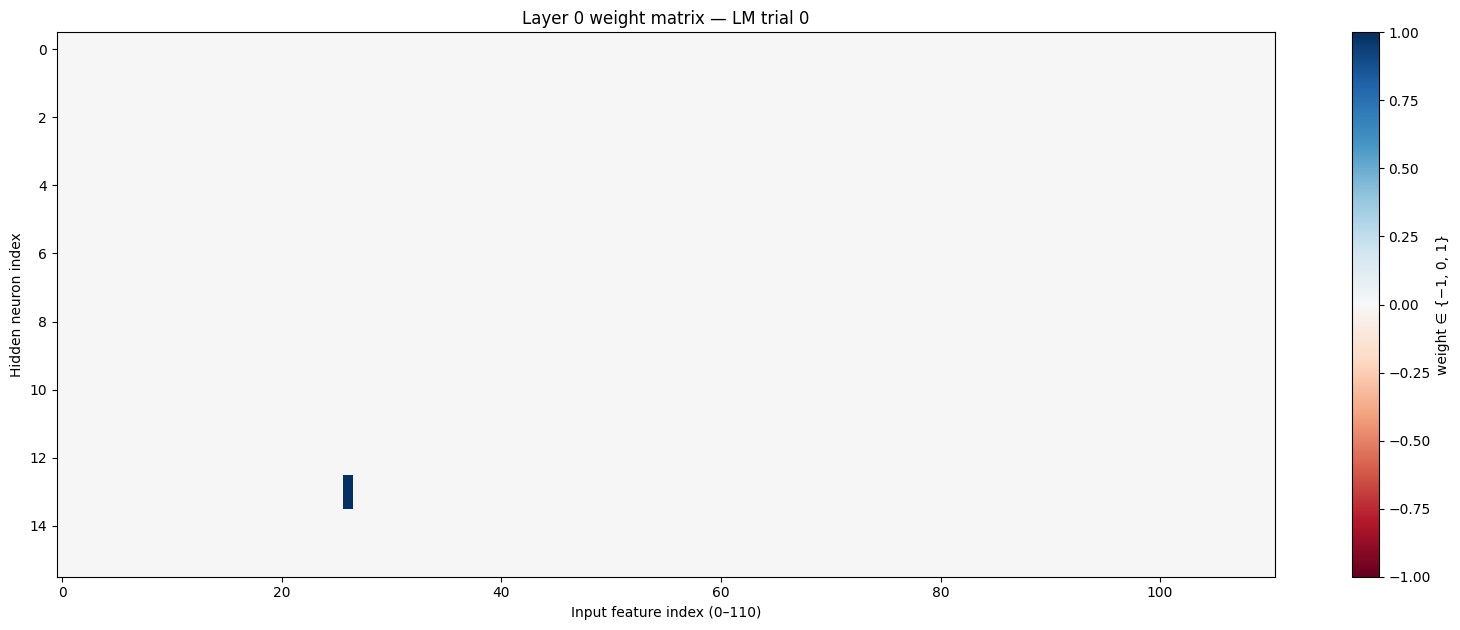


Active feature indices (1 of 111):
[26]


In [11]:
# Visualise weight matrix of layer 0 (111 features → hidden)
W0 = layers[0][0].round().int().numpy()

fig, ax = plt.subplots(figsize=(16, max(3, W0.shape[0] * 0.4)))
im = ax.imshow(W0, cmap='RdBu', vmin=-1, vmax=1, aspect='auto', interpolation='nearest')
ax.set_xlabel('Input feature index (0–110)')
ax.set_ylabel('Hidden neuron index')
ax.set_title(f'Layer 0 weight matrix — {best_row["method"]} trial {int(best_row["trial"])}')
plt.colorbar(im, ax=ax, label='weight ∈ {−1, 0, 1}')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/best_weights_layer0.png', dpi=150)
plt.show()

# Which input features have any non-zero weight?
active_mask = (W0 != 0).any(axis=0)
active_indices = np.where(active_mask)[0]
print(f'\nActive feature indices ({len(active_indices)} of {W0.shape[1]}):')
print(active_indices.tolist())

## 9 · Formula extraction from best crystallized model

In [12]:
# Try to extract formula from best crystallized model
crys_recs = [r for r in all_records if r['crystallized']]

if not crys_recs:
    print('No fully crystallized model found across all trials.')
    print('Attempting extraction on best model (may use approximation).')
    crys_recs = [best_rec]

# Sort by F1, pick top
crys_recs_sorted = sorted(crys_recs, key=lambda r: -r['f1'])
target = crys_recs_sorted[0]
print(f'Extracting from {target["method"]} trial {target["trial"]} '
      f'F1={target["f1"]:.4f} Δ(N)={target["delta_n"]:.6f}')

try:
    er = extract_formula(target['model'], n_values=3)
    print(f'\nRepresentable: {er.representable}')
    print('\nLayer formulas:')
    for li, syms in enumerate(er.layer_formulas):
        print(f'  Layer {li}:')
        for ni, sym in enumerate(syms):
            print(f'    N{ni}: {sym}')
    print(f'\nFinal formula:\n  {er.formula}')
except Exception as e:
    print(f'Extraction error: {e}')

Extracting from STE trial 0 F1=0.8797 Δ(N)=0.000000
Extraction error: numel: integer multiplication overflow


## 10 · Hyper-parameter sensitivity: learning rate effect (STE)

In [13]:
LR_SWEEP = [0.001, 0.003, 0.005, 0.008, 0.01]
N_LR_TRIALS = 3  # quick sweep — 3 restarts per lr

lr_rows = []
print('STE learning rate sweep...')
for lr in LR_SWEEP:
    for trial in range(N_LR_TRIALS):
        seed = 999 + trial * 100
        torch.manual_seed(seed)
        ds = load_mushroom(enrich=ENRICH, seed=seed)
        model = LukasiewiczNet(ds.n_features, HIDDEN_LAYERS, mode='ste')
        opt = STEOptimizer(model, lr=lr, clip_grad=1.0)
        res = opt.train(ds.X_train, ds.y_train,
                        tol_mse=TOL_MSE, max_iter=5000, verbose=False)
        with torch.no_grad():
            pred = model(ds.X_test)
        lr_rows.append({
            'lr': lr, 'trial': trial,
            'mse': res.final_mse,
            'f1': compute_f1(pred, ds.y_test),
            'delta_n': compute_delta_n(model),
        })
    print(f'  lr={lr}: done')

lr_df = pd.DataFrame(lr_rows)
lr_agg = lr_df.groupby('lr')[['mse','f1','delta_n']].mean().round(4)
print('\nLR sweep results:')
lr_agg

STE learning rate sweep...
  lr=0.001: done
  lr=0.003: done
  lr=0.005: done
  lr=0.008: done
  lr=0.01: done

LR sweep results:


,mse,f1,delta_n
lr,,,
0.0010,0.2106,0.5103,0.0000
0.0030,0.2391,0.3057,0.0000
0.0050,0.2439,0.7436,0.0000
0.0080,0.2542,0.7232,0.0000
0.0100,0.3037,0.4003,0.0000


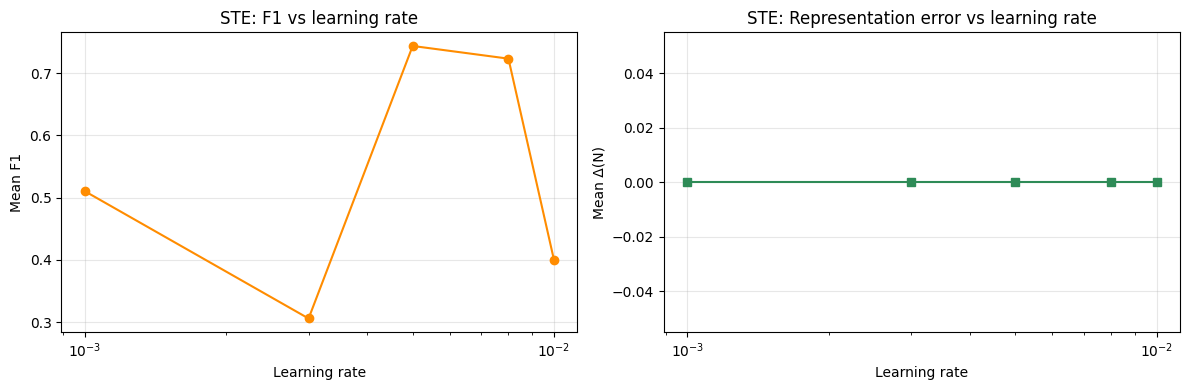

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lr_agg.index, lr_agg['f1'], 'o-', color='darkorange')
axes[0].set_xscale('log')
axes[0].set_xlabel('Learning rate')
axes[0].set_ylabel('Mean F1')
axes[0].set_title('STE: F1 vs learning rate')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lr_agg.index, lr_agg['delta_n'], 's-', color='seagreen')
axes[1].set_xscale('log')
axes[1].set_xlabel('Learning rate')
axes[1].set_ylabel('Mean Δ(N)')
axes[1].set_title('STE: Representation error vs learning rate')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/lr_sweep.png', dpi=150)
plt.show()

## 11 · Export results

In [15]:
cols = ['method','trial','mse','accuracy','f1','lambda','delta_n',
        'crystallized','converged','iterations','active_features','time_s','extracted_formula']
out = df[cols].sort_values(['method','trial'])
out.to_csv(f'{RESULTS_DIR}/all_trials.csv', index=False)
lr_df.to_csv(f'{RESULTS_DIR}/lr_sweep.csv', index=False)
print('Saved to', RESULTS_DIR)
out

Saved to ../results/mushroom


,method,trial,mse,accuracy,f1,lambda,delta_n,crystallized,converged,iterations,active_features,time_s,extracted_formula
0,LM,0,0.1289,0.6427,0.8805,0.8073,1151.0266,False,False,74,1,17.2720,NaN
1,LM,1,0.6570,0.3341,0.5009,0.5138,1158.9769,False,False,400,1,21.3436,NaN
2,LM,2,0.3042,0.5941,0.2889,0.7124,598.6356,False,False,57,77,12.6654,NaN
3,LM,3,0.3382,0.6468,0.0000,0.7024,971.4973,False,False,400,0,3.5096,NaN
4,LM,4,0.3395,0.6521,0.0000,0.7061,988.8264,False,False,400,21,5.9948,NaN
5,LM,5,0.2907,0.6496,0.2776,0.7284,0.0000,True,True,41,24,8.9050,[error: numel: integer multiplication overflow]
6,LM,6,0.0738,0.9258,0.8782,0.9247,607.0068,False,False,76,69,18.8375,NaN
7,LM,7,0.3409,0.6573,0.0000,0.7099,992.7816,False,False,400,18,3.7844,NaN
8,LM,8,0.3411,0.6582,0.0000,0.7105,911.0648,False,False,400,22,5.8657,NaN
9,LM,9,0.1436,0.6484,0.6017,0.8081,0.0000,True,True,47,1,16.3032,x27
